In [2]:
import pandas as pd


2. Charger et examiner les données
Tout d'abord, vous allez charger les données à partir du fichier winequality.csv dans un
DataFrame pandas et les examiner :

In [3]:
df = pd.read_csv("winequality.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0


La méthode head() affichera les cinq premières lignes du DataFrame. Vous pouvez voir que
l'ensemble de données contient 11 caractéristiques et une variable cible (qualité). Vous
utiliserez cette variable cible pour prédire la qualité du vin.

3. Prétraiter les données
Ensuite, vous allez prétraiter les données pour les préparer à la modélisation. Vous
commencerez par vérifier la présence de valeurs manquantes :

In [4]:
df.isnull().sum()

fixed acidity           73
volatile acidity        94
citric acid             79
residual sugar          79
chlorides               62
free sulfur dioxide     69
total sulfur dioxide    76
density                 84
pH                      94
sulphates               97
alcohol                 64
quality                 83
dtype: int64

In [5]:
df.fillna(df.mean(), inplace=True)

In [ ]:
# Commentaire : Avec isnull().sum(), on cherche à savoir le nombre de données manquantes pour chaque colonne puis on fillna(df.mean(), inplace=True) afin de compléter les valeures manquantes par la moyenne de la colonne en question.
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Vous devriez constater la présence de valeurs manquantes dans l'ensemble de données. Vous
allez imputer les valeurs manquantes en utilisant la moyenne. NB : Notez que le
remplacement par la moyenne n'est pas toujours une bonne solution. Il existe d'autres
techniques pouvant être utilisées pour remplir les données manquantes

Maintenant que vous avez imputé les valeurs manquantes, vous allez vérifier s'il y a des
points de données aberrants. Vous commencerez par examiner le résumé statistique des
caractéristiques :


In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.320183,0.526648,0.271336,2.542105,0.087310,15.884967,46.896257,0.996745,3.312219,0.657144,10.417101,5.636544
std,1.691527,0.172716,0.189322,1.391232,0.046136,10.287779,32.145059,0.001857,0.148811,0.165407,1.035983,0.789772
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.200000,0.400000,0.100000,1.900000,0.070500,8.000000,23.000000,0.995655,3.220000,0.550000,9.500000,5.000000
50%,8.000000,0.526648,0.270000,2.200000,0.080000,14.000000,40.000000,0.996745,3.312219,0.630000,10.200000,6.000000
75%,9.100000,0.630000,0.420000,2.600000,0.089000,21.000000,61.000000,0.997800,3.400000,0.720000,11.000000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.000000,8.000000


Cela vous montrera la moyenne, l'écart type, la valeur minimale, la valeur maximale et les
valeurs quartiles pour chaque caractéristique. Vous pouvez ensuite rechercher les
caractéristiques présentant une grande différence entre la moyenne et les valeurs maximales
ou minimales, car cela pourrait indiquer la présence de points de données aberrants.
Par exemple, supposons que vous remarquiez que la caractéristique "total sulfur dioxide"
présente une grande différence entre la moyenne et la valeur maximale :

La valeur maximale de 289 est bien plus élevée que la moyenne de 46,9, vous pourriez donc
soupçonner la présence de quelques points de données aberrants dans cette caractéristique.
Pour le confirmer, vous pouvez créer un graphique en boîte (box plot) de la caractéristique :

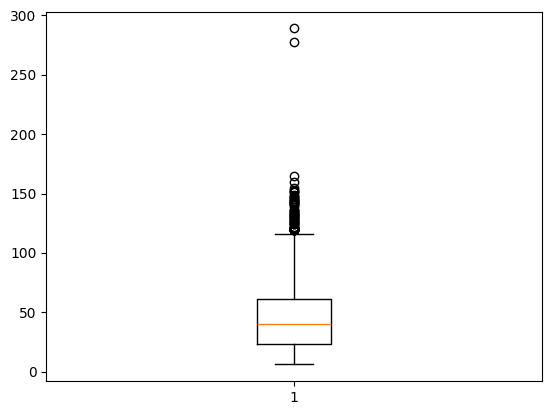

In [ ]:
import matplotlib.pyplot as plt

# Commentaire : On utilise une box plot afin de visualiser et comprendre les valeurs extrêmes de la colonne total sulfur dioxide dans ce cas. On constate 2 valeures abérantes dans le dataset.
plt.boxplot(df["total sulfur dioxide"])
plt.show()

Cela vous montrera les valeurs aberrantes (outliers) dans la caractéristique. Si vous trouvez
des valeurs aberrantes, vous pouvez les supprimer en utilisant la méthode de la plage
interquartile (IQR) (Interquartile Range (IQR) method) :

In [ ]:
# Commentaire : On applique IQR nous permettant de supprimer les valeures abérantes dans une plage définit.

Q1 = df["total sulfur dioxide"].quantile(0.25)
Q3 = df["total sulfur dioxide"].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df["total sulfur dioxide"] < (Q1 - 1.5 * IQR)) | (df["total sulfur dioxide"] > (Q3 +
1.5 * IQR)))]


4. Réaliser des visualisations de niveau intermédiaire
Maintenant que vous avez prétraité les données, vous réaliserez des visualisations de niveau
intermédiaire pour explorer les relations entre les caractéristiques et la variable cible.
Tout d'abord, vous créerez un histogramme de la variable cible :


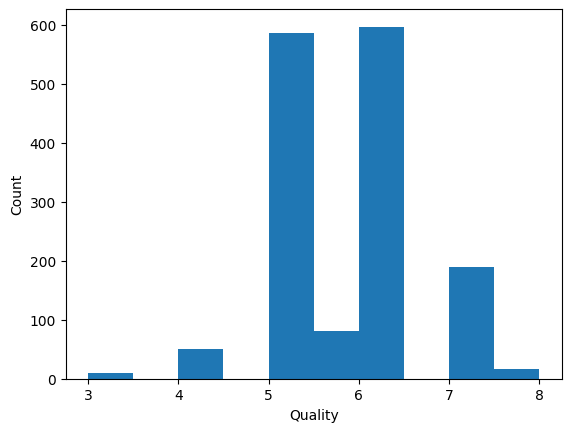

In [ ]:
plt.hist(df["quality"])
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()


Ensuite, vous créerez une carte de chaleur (Heatmap) pour visualiser la corrélation entre les
caractéristiques :


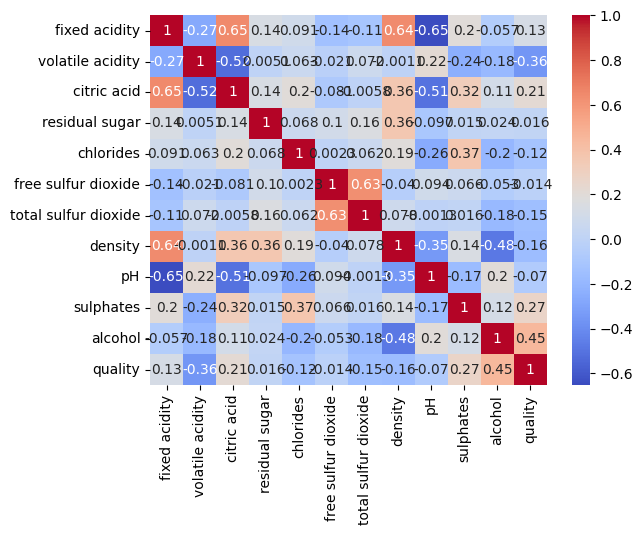

In [ ]:
import seaborn as sns

# Commentaire : corr() nous permet de visualiser les corrélation entre 2 caractéristiques et nous permets de créer de nouvelles caractéristiques à partir de celle-ci
# Par exemple si un dataset possède une forte corrélation entre le loyer et le revenue des locataires, on pourrait créer une nouvelle caractéristique loyer/revenu par locataires.

corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()


Vous devriez voir une carte de chaleur qui visualise la corrélation entre les caractéristiques.
Recherchez d'éventuelles corrélations fortes entre les caractéristiques, car elles pourraient
indiquer une multicollinéarité.
Enfin, vous créerez une matrice de diagrammes de dispersion (scatter plot matrix) pour
visualiser les relations entre les caractéristiques et la variable cible :


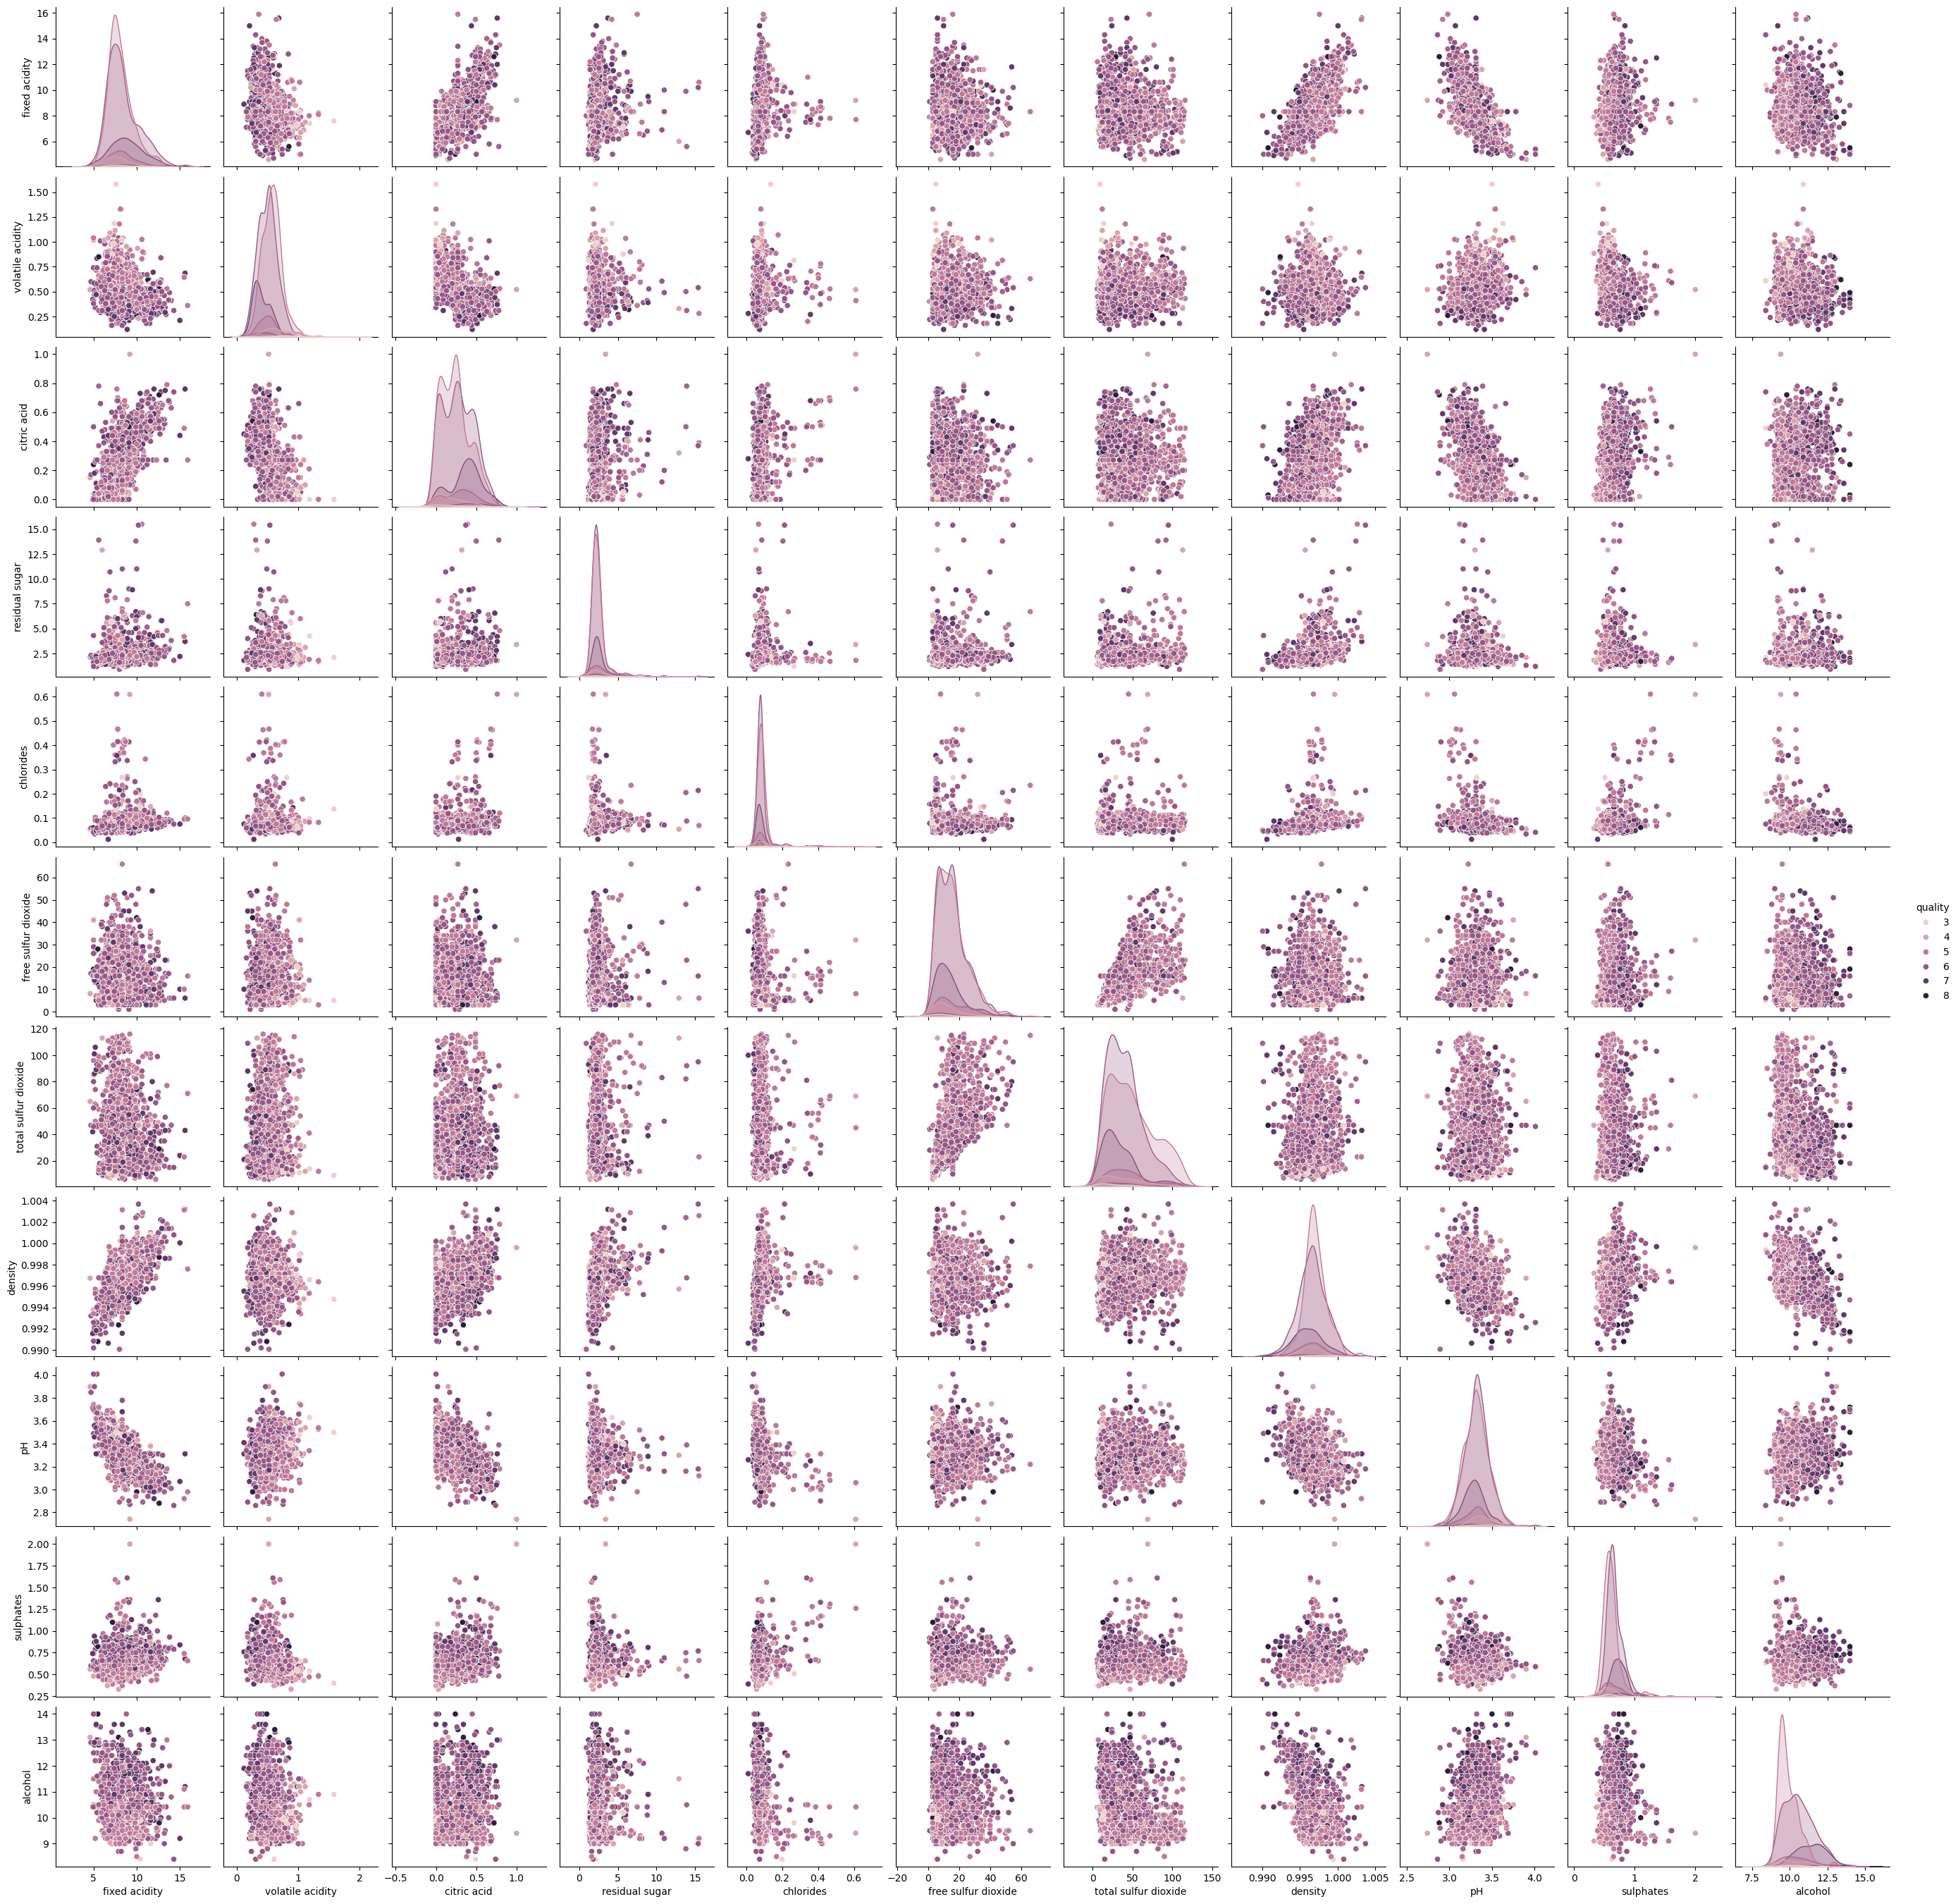

In [15]:
sns.pairplot(data=df, vars=["fixed acidity", "volatile acidity", "citric acid", "residual sugar",
"chlorides", "free sulfur dioxide", "total sulfur dioxide", "density", "pH", "sulphates",
"alcohol"], hue="quality")


Vous devriez voir une matrice de diagrammes de dispersion qui visualise les relations entre les
caractéristiques et la variable cible. Recherchez d'éventuels modèles ou corrélations qui
pourraient vous aider à prédire la variable cible.